# CMPT 733 Final Submission Demo

This notebook is the main reproducible entry point for the final project pipeline.

- Prediction target: `CURRENT_LAND_VALUE`
- Pipeline: clean property data -> standardize external sources -> build merged model table -> train final model
- Final takeaway: property/location/structure features dominate; Census is prepared but deferred by default


## 1) Environment / File Check
We first verify the required raw files before running the pipeline. Missing files are reported as warnings.

In [1]:
from pathlib import Path
import subprocess
import sys
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = Path.cwd()
print(f'Repository root: {ROOT}')

required_raw = {
    'property-tax-report.csv': ROOT / 'data/raw/property-tax-report.csv',
    'mortgage csv': ROOT / 'data/raw/statcan_mortgage_rate_5yr_20260228.csv',
    'IRCC PR xlsx': ROOT / 'data/raw/ircc_pr_cma_20260228.xlsx',
    'IRCC study permits xlsx': ROOT / 'data/raw/ircc_studypermits_pt_studylevel_20260228.xlsx',
    'CMHC csv': ROOT / 'data/raw/cmhc_vancouver_rental_supply_change_20260228.csv',
    'Census data csv': ROOT / 'data/raw/statcan_censusprofile2021_data_20260228.csv',
    'Census geoindex csv': ROOT / 'data/raw/statcan_censusprofile2021_geoindex_20260228.csv',
    'Census meta txt': ROOT / 'data/raw/statcan_censusprofile2021_meta_20260228.txt',
}

print('Raw data checklist:')
missing = []
for label, path in required_raw.items():
    exists = path.exists()
    status = 'OK' if exists else 'MISSING'
    print(f'  [{status}] {label}: {path}')
    if not exists:
        missing.append((label, path))

if missing:
    print('\nWARNING: Some required raw files are missing. You can still run cells, but pipeline steps may fail.')

def run_step(cmd, title):
    print(f'\n=== {title} ===')
    print('Command:', ' '.join(cmd))
    try:
        result = subprocess.run(cmd, check=True, text=True, capture_output=True)
        if result.stdout.strip():
            print(result.stdout)
        if result.stderr.strip():
            print('[stderr]')
            print(result.stderr)
        print(f'Completed: {title}')
        return True
    except subprocess.CalledProcessError as e:
        print(f'ERROR in {title}:')
        print(e.stdout or '')
        print(e.stderr or '')
        return False


Repository root: c:\Users\29430\OneDrive - Simon Fraser University (1sfu)\SFU\CMPT733\cmpt733-final-project
Raw data checklist:
  [OK] property-tax-report.csv: c:\Users\29430\OneDrive - Simon Fraser University (1sfu)\SFU\CMPT733\cmpt733-final-project\data\raw\property-tax-report.csv
  [OK] mortgage csv: c:\Users\29430\OneDrive - Simon Fraser University (1sfu)\SFU\CMPT733\cmpt733-final-project\data\raw\statcan_mortgage_rate_5yr_20260228.csv
  [OK] IRCC PR xlsx: c:\Users\29430\OneDrive - Simon Fraser University (1sfu)\SFU\CMPT733\cmpt733-final-project\data\raw\ircc_pr_cma_20260228.xlsx
  [OK] IRCC study permits xlsx: c:\Users\29430\OneDrive - Simon Fraser University (1sfu)\SFU\CMPT733\cmpt733-final-project\data\raw\ircc_studypermits_pt_studylevel_20260228.xlsx
  [OK] CMHC csv: c:\Users\29430\OneDrive - Simon Fraser University (1sfu)\SFU\CMPT733\cmpt733-final-project\data\raw\cmhc_vancouver_rental_supply_change_20260228.csv
  [OK] Census data csv: c:\Users\29430\OneDrive - Simon Fraser Un

## 2) Clean Property Tax Data
This step cleans and filters the City property-tax file into a stable modeling table.

In [2]:
ok_clean = run_step([
    sys.executable, '-m', 'src.data.clean_property_tax',
    '--in_path', 'data/raw/property-tax-report.csv',
    '--out_path', 'data/interim/property_tax_clean.parquet'
], 'Clean property tax data')

clean_summary = ROOT / 'reports/figures/property_tax_clean_summary.csv'
if clean_summary.exists():
    print('Displaying property clean summary:')
    display(pd.read_csv(clean_summary).head(30))
else:
    print('Property clean summary CSV not found yet.')


=== Clean property tax data ===
Command: C:\Users\29430\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m src.data.clean_property_tax --in_path data/raw/property-tax-report.csv --out_path data/interim/property_tax_clean.parquet
Completed: Clean property tax data
Displaying property clean summary:


,section,metric,value
0,rows,total_rows_before,1.551133e+06
1,rows,total_rows_after,1.525600e+06
2,missing_rate,CURRENT_LAND_VALUE,0.000000e+00
3,missing_rate,YEAR_BUILT,2.858200e-02
4,missing_rate,BIG_IMPROVEMENT_YEAR,2.859100e-02
5,missing_rate,LAND_COORDINATE,0.000000e+00
6,missing_rate,PROPERTY_POSTAL_CODE,0.000000e+00
7,count_by_report_year,2020,2.124460e+05
8,count_by_report_year,2021,2.136090e+05
9,count_by_report_year,2022,2.167190e+05


## 3) Standardize External Datasets
We standardize mortgage, immigration, rental, and census sources into consistent intermediate tables.

In [3]:
standardize_steps = [
    ('Standardize mortgage', [sys.executable, '-m', 'src.data.standardize_mortgage_rate']),
    ('Standardize IRCC PR', [sys.executable, '-m', 'src.data.standardize_ircc_pr']),
    ('Standardize IRCC study permits', [sys.executable, '-m', 'src.data.standardize_ircc_study_permits']),
    ('Standardize CMHC rental', [sys.executable, '-m', 'src.data.standardize_cmhc_rental']),
    ('Standardize census profile', [sys.executable, '-m', 'src.data.standardize_census_profile']),
]

for title, cmd in standardize_steps:
    run_step(cmd, title)

summary_files = [
    'reports/figures/mortgage_rate_yearly_summary.csv',
    'reports/figures/ircc_pr_yearly_summary.csv',
    'reports/figures/ircc_study_permits_yearly_summary.csv',
    'reports/figures/cmhc_rental_yearly_summary.csv',
    'reports/figures/census_profile_standardized_summary.csv',
]

for s in summary_files:
    p = ROOT / s
    print(f'\nSummary file: {p}')
    if p.exists():
        display(pd.read_csv(p).head(20))
    else:
        print('Not found.')


=== Standardize mortgage ===
Command: C:\Users\29430\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m src.data.standardize_mortgage_rate
[mortgage] Reading raw file: data\raw\statcan_mortgage_rate_5yr_20260228.csv
[mortgage] Saved yearly parquet: data\interim\mortgage_rate_yearly.parquet
[mortgage] Saved summary CSV: reports\figures\mortgage_rate_yearly_summary.csv
[mortgage] Year coverage: 1951 - 2026

Completed: Standardize mortgage

=== Standardize IRCC PR ===
Command: C:\Users\29430\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m src.data.standardize_ircc_pr
[ircc_pr] Reading workbook: data\raw\ircc_pr_cma_20260228.xlsx (sheet=PR - CMA)
[ircc_pr] Saved yearly parquet: data\interim\ircc_pr_yearly.parquet
[ircc_pr] Saved summary CSV: reports\figures\ircc_pr_yearly_summary.csv
[ircc_pr] Using Vancouver CMA series from PR - CMA sheet.

Completed: Standardize IRCC PR

=== Standardiz

,REPORT_YEAR,mortgage_rate_5yr_avg,mortgage_rate_5yr_end_of_year
0,1951,5.750000,5.75
1,1952,5.770833,5.80
2,1953,5.970833,6.10
3,1954,6.012500,6.00
4,1955,5.879167,5.95
5,1956,6.225000,6.65
6,1957,6.854167,6.95
7,1958,6.795833,6.80
8,1959,6.975000,7.25
9,1960,7.175000,7.00



Summary file: c:\Users\29430\OneDrive - Simon Fraser University (1sfu)\SFU\CMPT733\cmpt733-final-project\reports\figures\ircc_pr_yearly_summary.csv


,REPORT_YEAR,ircc_pr_vancouver_cma,ircc_pr_bc_total,note
0,2015,28375.0,35720.0,Using Vancouver CMA series from PR - CMA sheet.
1,2016,29770.0,38085.0,Using Vancouver CMA series from PR - CMA sheet.
2,2017,29850.0,38465.0,Using Vancouver CMA series from PR - CMA sheet.
3,2018,35255.0,44855.0,Using Vancouver CMA series from PR - CMA sheet.
4,2019,39945.0,50230.0,Using Vancouver CMA series from PR - CMA sheet.
5,2020,22740.0,28485.0,Using Vancouver CMA series from PR - CMA sheet.
6,2021,53925.0,69470.0,Using Vancouver CMA series from PR - CMA sheet.
7,2022,48415.0,61240.0,Using Vancouver CMA series from PR - CMA sheet.
8,2023,54910.0,70820.0,Using Vancouver CMA series from PR - CMA sheet.
9,2024,47590.0,63125.0,Using Vancouver CMA series from PR - CMA sheet.



Summary file: c:\Users\29430\OneDrive - Simon Fraser University (1sfu)\SFU\CMPT733\cmpt733-final-project\reports\figures\ircc_study_permits_yearly_summary.csv


,REPORT_YEAR,study_permits_bc_total,note
0,2015,56750.0,Using BC total yearly counts. Category-specifi...
1,2016,65650.0,Using BC total yearly counts. Category-specifi...
2,2017,76375.0,Using BC total yearly counts. Category-specifi...
3,2018,81615.0,Using BC total yearly counts. Category-specifi...
4,2019,86065.0,Using BC total yearly counts. Category-specifi...
5,2020,58980.0,Using BC total yearly counts. Category-specifi...
6,2021,94070.0,Using BC total yearly counts. Category-specifi...
7,2022,110705.0,Using BC total yearly counts. Category-specifi...
8,2023,127250.0,Using BC total yearly counts. Category-specifi...
9,2024,101595.0,Using BC total yearly counts. Category-specifi...



Summary file: c:\Users\29430\OneDrive - Simon Fraser University (1sfu)\SFU\CMPT733\cmpt733-final-project\reports\figures\cmhc_rental_yearly_summary.csv


,REPORT_YEAR,cmhc_rental_supply_net_change_total,cmhc_rental_supply_new_added,cmhc_rental_supply_existing_converted
0,2014,938,2011,-1637
1,2015,5809,2040,2935
2,2016,2438,4312,-2796
3,2017,2470,1367,474
4,2018,-288,1911,-2992
5,2019,12582,2294,8824
6,2020,9525,3506,3631
7,2021,4152,2976,-426
8,2022,11655,4554,3296
9,2023,9473,2561,3768



Summary file: c:\Users\29430\OneDrive - Simon Fraser University (1sfu)\SFU\CMPT733\cmpt733-final-project\reports\figures\census_profile_standardized_summary.csv


,section,metric,value
0,meta,target_geographies,2.0
1,missing_rate,census_population_2021,0.0
2,missing_rate,census_avg_household_size,0.0
3,missing_rate,census_median_household_income_2020,0.0
4,missing_rate,census_owner_households,0.0
5,missing_rate,census_renter_households,0.0
6,missing_rate,census_age_65_plus_pct,0.0


## 4) Build Merged Model Table
This step builds the final merged feature table from property data, engineered history features, and external yearly signals.

Census is deferred by default. (`--merge_census` exists but is not run here by default.)

In [4]:
ok_table = run_step([sys.executable, '-m', 'src.data.build_model_table'], 'Build merged model table')

table_summary = ROOT / 'reports/figures/model_table_summary.csv'
if table_summary.exists():
    print('Displaying model table summary:')
    display(pd.read_csv(table_summary).head(40))
else:
    print('Model table summary CSV not found yet.')


=== Build merged model table ===
Command: C:\Users\29430\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m src.data.build_model_table
[model_table] Loading property fact table: data/interim/property_tax_clean.parquet
[model_table] Saved: data\processed\model_table.parquet
[model_table] Saved summary: reports\figures\model_table_summary.csv
[model_table] Rows=1,525,600, Cols=60

Completed: Build merged model table
Displaying model table summary:


,section,metric,value
0,table,fact_rows_before,1525600
1,engineered_property_feature,REPORT_YEAR_NUM,created
2,engineered_property_feature,REPORT_YEAR_CENTERED,created
3,engineered_property_feature,PROPERTY_AGE,created
4,engineered_property_feature,BUILDING_AGE_BIN,created
5,engineered_property_feature,YEARS_SINCE_IMPROVEMENT,created
6,engineered_property_feature,HAS_BIG_IMPROVEMENT,created
7,engineered_property_feature,IMPROVEMENT_RECENCY_BIN,created
8,engineered_property_feature,POSTAL_FSA,created
9,engineered_property_feature,LEGAL_ZONING_COMBO,created


## 5) Train and Evaluate Final Model
This runs the consolidated final model script and writes metrics, plots, and feature-importance outputs.

In [5]:
ok_model = run_step([sys.executable, '-m', 'src.models.train_model'], 'Train final model')

metrics_path = ROOT / 'reports/figures/model_metrics.csv'
if metrics_path.exists():
    print('Final model metrics:')
    display(pd.read_csv(metrics_path))
else:
    print('Model metrics CSV not found yet.')


=== Train final model ===
Command: C:\Users\29430\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m src.models.train_model
[train_model] Using model backend: hist_gradient_boosting
Test y_true stats (p50/p90/p99/max): 1050000.00, 2928000.00, 11698000.00, 3637869000.00
Test y_pred stats (p50/p90/p99/max): 801314.48, 3081802.19, 6794958.14, 64847454.51
Test RMSE: 9,998,813.17
Test MAE: 691,434.48
Test Median APE: 0.1818
Robust cap (p99.5 train): 24,533,950.00
Robust RMSE: 1,657,883.65
Robust MAE: 489,160.08

[stderr]
C:\Users\29430\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This

,model,rmse,mae,median_ape,robust_rmse,robust_mae,robust_cap_p99_5,n_train,n_test,n_features_total,n_features_cat,n_features_num,model_backend
0,model_hist_gradient_boosting,9.998813e+06,691434.482372,0.181839,1.657884e+06,489160.081621,24533950.0,860843.0,664757.0,57.0,9.0,48.0,hist_gradient_boosting


## 6) Final Visual Outputs
Below are the main final figures for interpretation.

### Model Scatter

Points near the diagonal indicate predictions close to official values.

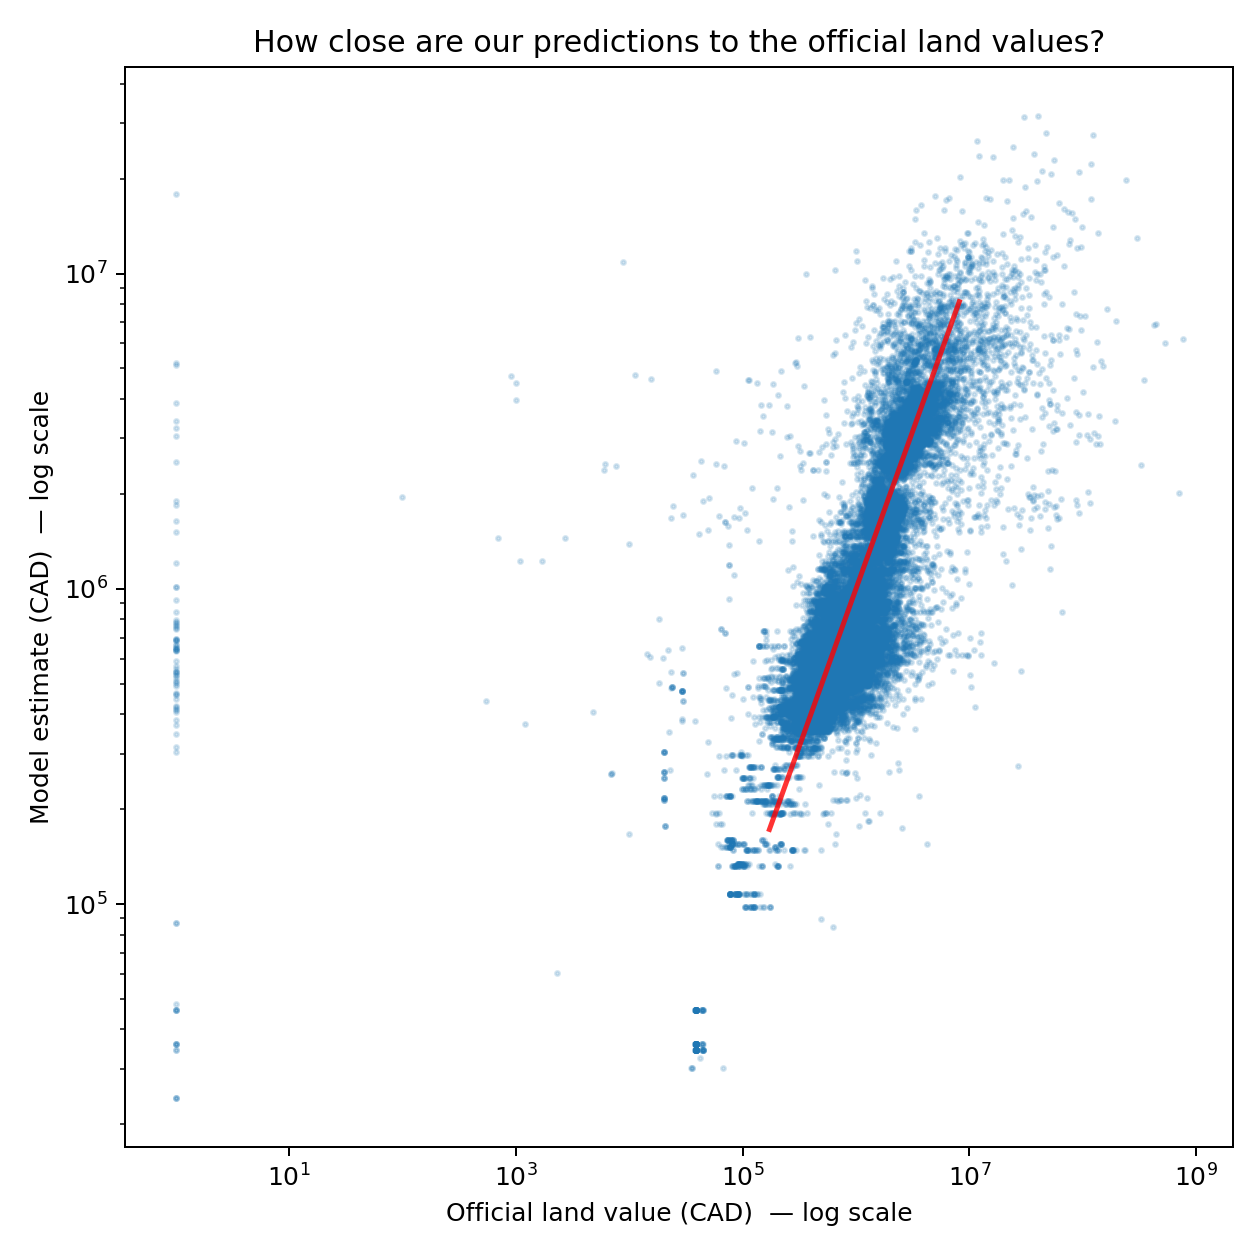

### Error Distribution

Center near zero suggests limited overall bias; long tails indicate harder properties.

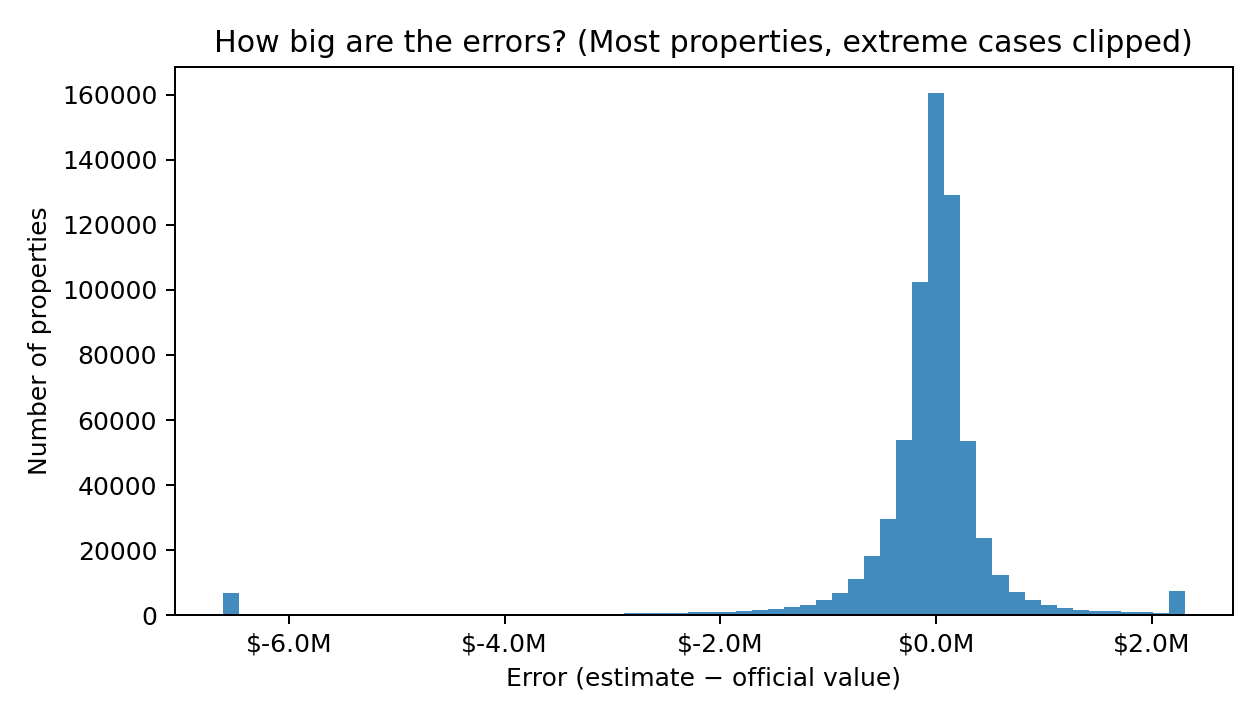

### Neighbourhood Difficulty

Higher bars indicate neighbourhoods that are systematically harder to estimate.

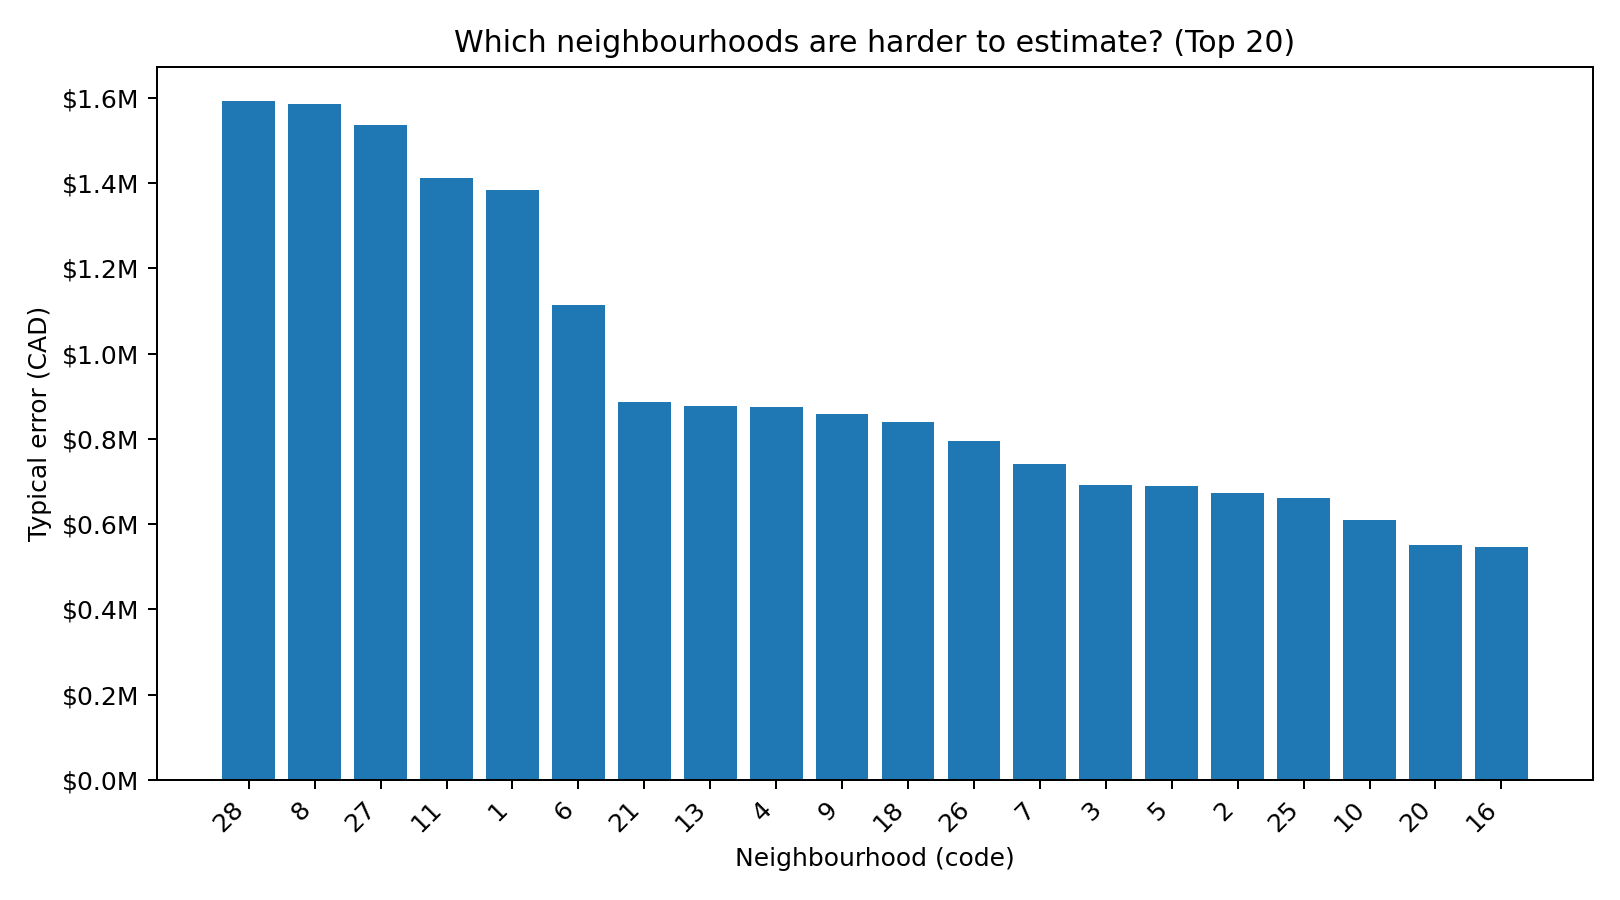

### Feature Importance

The model relies mostly on property/location/structure variables; yearly macro features contribute less.

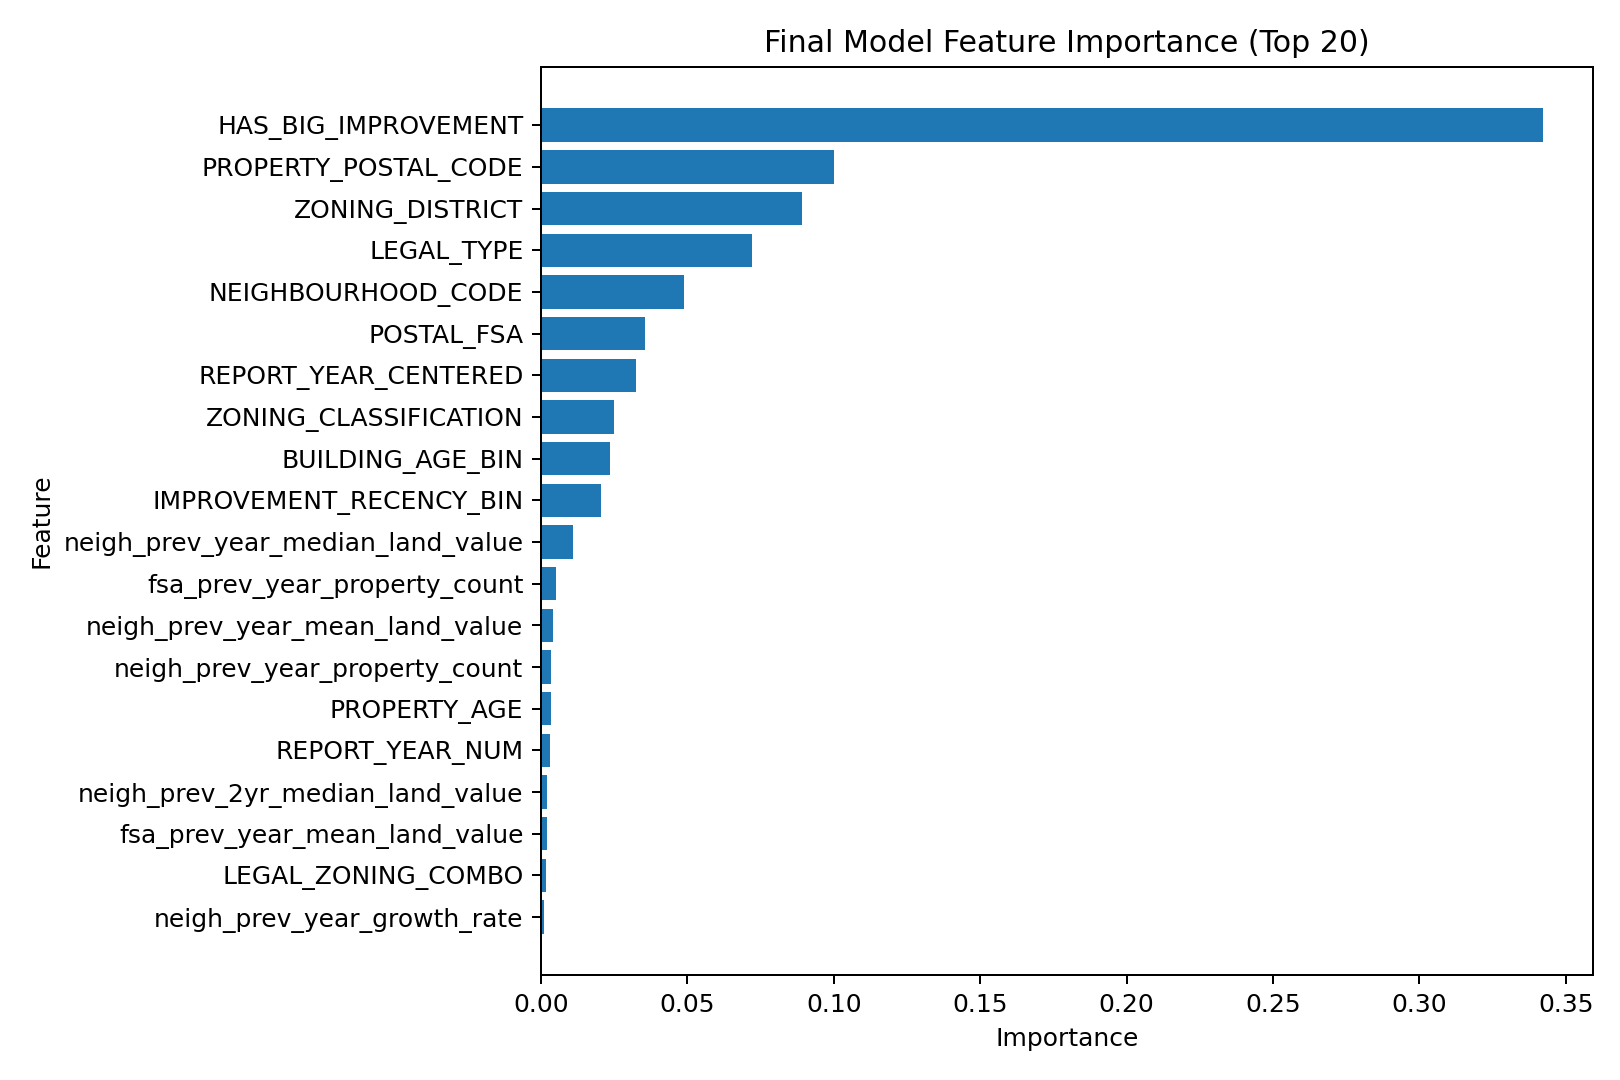

In [6]:
figure_items = [
    ('### Model Scatter', 'Points near the diagonal indicate predictions close to official values.', 'reports/figures/model_scatter_public.png'),
    ('### Error Distribution', 'Center near zero suggests limited overall bias; long tails indicate harder properties.', 'reports/figures/model_error_distribution_public.png'),
    ('### Neighbourhood Difficulty', 'Higher bars indicate neighbourhoods that are systematically harder to estimate.', 'reports/figures/model_neighbourhood_difficulty_public.png'),
    ('### Feature Importance', 'The model relies mostly on property/location/structure variables; yearly macro features contribute less.', 'reports/figures/model_feature_importance_top20.png'),
]

for title, note, rel_path in figure_items:
    display(Markdown(title))
    display(Markdown(note))
    p = ROOT / rel_path
    if p.exists():
        display(Image(filename=str(p)))
    else:
        print(f'Figure not found: {p}')

## 7) Final Interpretation Tables
These tables provide feature-level and neighbourhood-level interpretation details.

In [7]:
tables_to_show = [
    ('Feature importance (all)', 'reports/figures/model_feature_importance.csv', 30),
    ('Feature importance (grouped)', 'reports/figures/model_feature_importance_grouped.csv', 20),
    ('Neighbourhood error (top rows)', 'reports/figures/model_neighbourhood_error.csv', 30),
]

for label, rel_path, n in tables_to_show:
    p = ROOT / rel_path
    print(f'\n{label}: {p}')
    if p.exists():
        display(pd.read_csv(p).head(n))
    else:
        print('Not found.')


Feature importance (all): c:\Users\29430\OneDrive - Simon Fraser University (1sfu)\SFU\CMPT733\cmpt733-final-project\reports\figures\model_feature_importance.csv


,feature,base_feature,importance,importance_abs,importance_rank,importance_share,feature_group
0,num__HAS_BIG_IMPROVEMENT,HAS_BIG_IMPROVEMENT,0.342155,0.342155,1,0.412771,property_location_structure
1,cat__PROPERTY_POSTAL_CODE,PROPERTY_POSTAL_CODE,0.100233,0.100233,2,0.120920,property_location_structure
2,cat__ZONING_DISTRICT,ZONING_DISTRICT,0.089010,0.089010,3,0.107380,property_location_structure
3,cat__LEGAL_TYPE,LEGAL_TYPE,0.072202,0.072202,4,0.087103,property_location_structure
4,cat__NEIGHBOURHOOD_CODE,NEIGHBOURHOOD_CODE,0.048908,0.048908,5,0.059001,property_location_structure
5,cat__POSTAL_FSA,POSTAL_FSA,0.035551,0.035551,6,0.042889,property_location_structure
6,num__REPORT_YEAR_CENTERED,REPORT_YEAR_CENTERED,0.032321,0.032321,7,0.038992,other
7,cat__ZONING_CLASSIFICATION,ZONING_CLASSIFICATION,0.024956,0.024956,8,0.030107,property_location_structure
8,cat__BUILDING_AGE_BIN,BUILDING_AGE_BIN,0.023553,0.023553,9,0.028413,property_location_structure
9,cat__IMPROVEMENT_RECENCY_BIN,IMPROVEMENT_RECENCY_BIN,0.020421,0.020421,10,0.024636,other



Feature importance (grouped): c:\Users\29430\OneDrive - Simon Fraser University (1sfu)\SFU\CMPT733\cmpt733-final-project\reports\figures\model_feature_importance_grouped.csv


,feature_group,group_importance,group_importance_share
0,property_location_structure,0.740137,0.892892
1,other,0.061298,0.073949
2,local_history,0.027285,0.032916
3,macro_temporal,0.000202,0.000244



Neighbourhood error (top rows): c:\Users\29430\OneDrive - Simon Fraser University (1sfu)\SFU\CMPT733\cmpt733-final-project\reports\figures\model_neighbourhood_error.csv


,NEIGHBOURHOOD_CODE,count,mean_abs_error,rmse,median_ape
0,1,13117,1.384282e+06,1.211585e+07,0.192049
1,10,9761,6.098983e+05,2.701787e+06,0.146009
2,11,10791,1.411134e+06,2.115844e+07,0.215742
3,12,20542,4.513251e+05,2.547890e+06,0.191845
4,13,56030,8.760811e+05,7.135915e+06,0.234213
5,14,31060,5.242727e+05,3.867027e+06,0.144334
6,15,17404,4.076685e+05,2.121767e+06,0.168662
7,16,20482,5.457647e+05,5.997796e+06,0.116564
8,17,19737,3.755365e+05,3.811089e+06,0.106736
9,18,17281,8.398148e+05,4.945391e+06,0.224275


## 8) Final Summary
- This pipeline predicts `CURRENT_LAND_VALUE` using cleaned property data plus merged external/context features.
- Property/location/structure features remain the strongest predictive signals.
- Broad yearly macro variables add limited value in the current setup.
- Census is standardized and available, but deferred by default unless a robust geography match is available.